In [1]:
from functions.internal import load_dataset_1B, normalization
from functions.SQUIC_functions import squic_fit_matrix_computation, squic_fit_computation, check_symmetric_sparse
from functions.clustering_functions import clustering_optimal_number, modularity_density
import matplotlib.pyplot as plt
import json
from scipy import sparse
from sklearn.neighbors import NearestNeighbors
import pandas as pd
import numpy as np
import os
from functions.plots import plot_timeseries, plot_knn, plot_PDens_Q
from functions.main_functions import load_presaved_data, normal_run, run_squic_fit, run_squic, show_df, ask_input, ask_yes_no
from functions.cosmograph_functions import visualize_graph_external

In [2]:
user_input = ask_yes_no("\nDo you want to load data?")



In [3]:
results_squic = {}

name = 'AMLSIM'

if user_input == 'Y':
    Y_norm, knn_matrix, account_prop, dimension = load_presaved_data(name)

else: # Normal run
    Y_norm, knn_matrix, account_prop, dimension = normal_run(name)

results_squic = {}

# Run SQUIC_fit
if ask_yes_no("SQUIC-Fit with bias or no?") == 'Y':
    results_squic, squic_method, save = run_squic_fit(Y_norm, knn_matrix, results_squic, name, dimension)

else:
    results_squic, squic_method, save = run_squic(Y_norm, results_squic, name, dimension)

Head of Y_norm df:
          0             1         2         3         4         5         6  \
0  0.279429  2.794292e-01  0.384253  0.489077  0.489077  0.489077  0.489077   
1  0.142518  1.152051e-17  0.010036  0.010036  0.018062  0.018062  0.026088   
2  0.609647  6.096475e-01  0.609647  0.609647  0.853103  0.243499  0.285984   
3  0.251678  2.516778e-01  0.276428  0.276428  0.276428  0.276428  0.276428   
4  1.137171  1.375396e+00  1.468549  1.468549  2.136344  1.538752  1.538752   

          7         8         9  ...       190       191       192       193  \
0  0.567176  0.567176  0.567176  ... -2.197391 -2.197391 -2.092568 -1.987744   
1  0.026088  0.026088  0.026088  ... -3.099343 -3.099343 -3.099343 -3.241861   
2  0.285984 -0.122650 -0.122650  ... -3.947603 -3.947603 -3.947603 -3.947603   
3  0.276428  0.356315  0.436203  ... -1.977817 -1.858705 -1.858705 -1.858705   
4  1.538752  1.538752  1.776976  ...  4.806399  5.172990  5.172990  5.172990   

        194       195    

Is G connected for l=0.2? True
Is G connected for l=0.1? True
Is G connected for l=0.09? True
Is G connected for l=0.05? True
Is G connected for l=0.01? True
For rho 0.2:
    louvain: PDensity = 0.48, Int Density = 0.55, Q = 0.52, nCluster = 4, nIsolated  = 0
    leiden: PDensity = 0.56, Int Density = 0.66, Q = 0.52, nCluster = 5, nIsolated  = 0
    dbscan: PDensity = 0.36, Int Density = 0.13, Q = 0.46, nCluster = 6, nIsolated  = 4
    spectral: PDensity = 0.35, Int Density = 0.38, Q = 0.47, nCluster = 2, nIsolated  = 0
For rho 0.1:
    louvain: PDensity = 0.41, Int Density = 0.5, Q = 0.51, nCluster = 4, nIsolated  = 0
    leiden: PDensity = 0.45, Int Density = 0.6, Q = 0.5, nCluster = 5, nIsolated  = 0
    dbscan: PDensity = 0.28, Int Density = 0.08, Q = 0.43, nCluster = 9, nIsolated  = 7
    spectral: PDensity = 0.28, Int Density = 0.32, Q = 0.45, nCluster = 2, nIsolated  = 0
For rho 0.09:
    louvain: PDensity = 0.38, Int Density = 0.48, Q = 0.51, nCluster = 4, nIsolated  = 0
    le

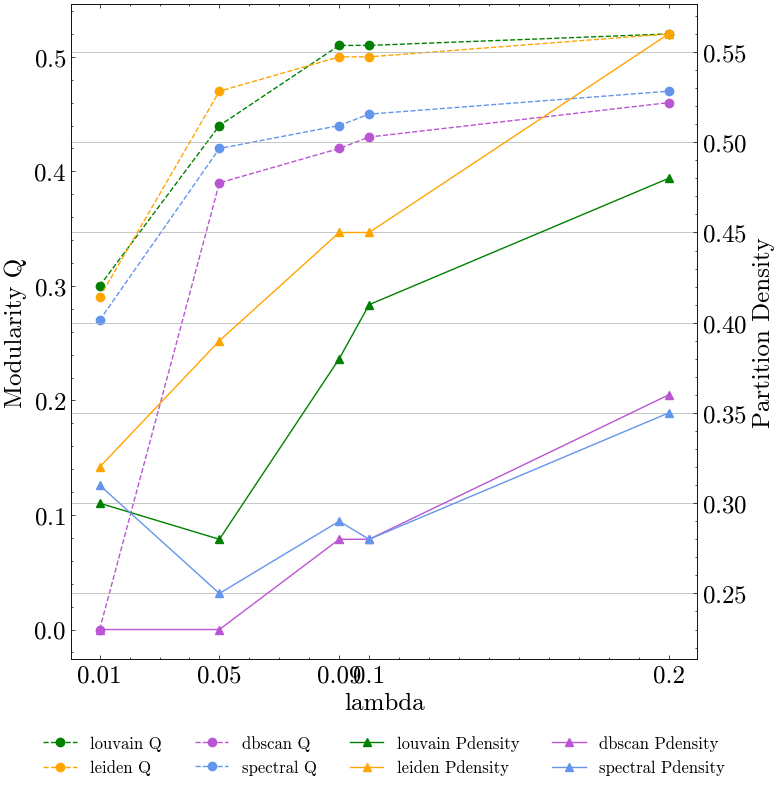

In [4]:
# Results
dict_cluster = clustering_optimal_number(dimension, results_squic, plot=False)

metrics = modularity_density(dict_cluster, results_squic, leiden=True)

for rho, data in metrics.items():
    print(f"For rho {rho}:")
    for method, results in data.items():
        print(f"    {method}: PDensity = {results['p_density']}, Int Density = {results['int_density']}, Q = {results['modularity']}, nCluster = {results['nCluster']}, nIsolated  = {results['isolated']}")

plot_PDens_Q(name, metrics, dimension, squic_method, save)

In [5]:
graph = visualize_graph_external(results_squic, squic_method, dict_cluster, account_prop)

In [6]:
lambda_graph = {
    '100': 0.09,
    '1K': 0.9999,
    '10K': 0.999999,
    '100K': 0.99999999
}

In [8]:
graph[lambda_graph.get(dimension)]['leiden']

Cosmograph(background_color='#FFFFFF', focused_point_ring_color=None, hovered_point_ring_color=None, link_colo…